# 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import os
df_items = pd.read_csv("olist_order_items_dataset.csv")
df_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_products = pd.read_csv("olist_products_dataset.csv")
# df_geolocation = pd.read_csv('olist_geolocation_dataset.csv'))
df_sellers = pd.read_csv("olist_sellers_dataset.csv")
df_payments = pd.read_csv("olist_order_payments_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
# df_category = pd.read_csv('product_category_name_translation.csv'))


# 데이터 합치기

In [2]:
# 기본 주문 정보
df = df_orders
# 주문 아이템 정보 추가 (order_id 기준)
df = df.merge(df_items, on="order_id", how="outer")
# 결제 정보 추가 (order_id 기준, df_payments는 order_id 기준으로 다:다 가능하므로 validate='m:m')
df = df.merge(df_payments, on="order_id", how="outer")
# 리뷰 정보 추가 (order_id 기준)
df = df.merge(df_reviews, on="order_id", how="outer")
# 제품 정보 추가 (product_id 기준)
df = df.merge(df_products, on="product_id", how="outer")
# 고객 정보 추가 (customer_id 기준)
df = df.merge(df_customers, on="customer_id", how="outer")
# 판매자 정보 추가 (seller_id 기준)
df = df.merge(df_sellers, on="seller_id", how="outer")

# 최종 병합된 데이터셋 저장
# df.to_csv('merged_data.csv', encoding='utf-8')

# 결측치 처리 (Task 1)

In [3]:
# 데이터 기본 정보 및 결측치 확인
print("데이터 형태(Shape):", df.shape)
print("\n--- 데이터 타입 및 결측치 개수 ---")
print(df.info())

데이터 형태(Shape): (119143, 39)

--- 데이터 타입 및 결측치 개수 ---
<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  str    
 1   customer_id                    119143 non-null  str    
 2   order_status                   119143 non-null  str    
 3   order_purchase_timestamp       119143 non-null  str    
 4   order_approved_at              118966 non-null  str    
 5   order_delivered_carrier_date   117057 non-null  str    
 6   order_delivered_customer_date  115722 non-null  str    
 7   order_estimated_delivery_date  119143 non-null  str    
 8   order_item_id                  118310 non-null  float64
 9   product_id                     118310 non-null  str    
 10  seller_id                      118310 non-null  str    
 11  shipping_limit_date            118310 non-null  s

In [4]:
# 컬럼별 결측치 비율 확인
missing_percentage = df.isnull().mean() * 100
print("\n--- 컬럼별 결측치 비율(%) ---")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


--- 컬럼별 결측치 비율(%) ---
review_comment_title             88.258647
review_comment_message           57.827988
order_delivered_customer_date     2.871339
product_name_lenght               2.133571
product_category_name             2.133571
product_description_lenght        2.133571
product_photos_qty                2.133571
order_delivered_carrier_date      1.750837
review_score                      0.836810
review_creation_date              0.836810
review_id                         0.836810
review_answer_timestamp           0.836810
product_weight_g                  0.715946
product_length_cm                 0.715946
product_width_cm                  0.715946
product_height_cm                 0.715946
product_id                        0.699160
seller_id                         0.699160
order_item_id                     0.699160
price                             0.699160
shipping_limit_date               0.699160
freight_value                     0.699160
seller_city                    

In [5]:
# 결측치 비율 높은 (20% 이상) 열 제거
df = df.drop(columns=missing_percentage[missing_percentage > 20].index)

In [6]:
# 나머지 열들 확인 결과, 모두 결측 비율 5% 미만이므로
# 결측치 모두 제거
df = df.dropna()

In [7]:
# 확인
print(df.shape)
df.info()

(113216, 37)
<class 'pandas.DataFrame'>
Index: 113216 entries, 0 to 118309
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113216 non-null  str    
 1   customer_id                    113216 non-null  str    
 2   order_status                   113216 non-null  str    
 3   order_purchase_timestamp       113216 non-null  str    
 4   order_approved_at              113216 non-null  str    
 5   order_delivered_carrier_date   113216 non-null  str    
 6   order_delivered_customer_date  113216 non-null  str    
 7   order_estimated_delivery_date  113216 non-null  str    
 8   order_item_id                  113216 non-null  float64
 9   product_id                     113216 non-null  str    
 10  seller_id                      113216 non-null  str    
 11  shipping_limit_date            113216 non-null  str    
 12  price                          11

# 이상치 처리

In [8]:
# IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print(f"이상치: {len(outliers)} 개")
outliers[['price']].sort_values(by='price', ascending=False).head(10)

이상치: 8473 개


,price
105744,6735.00
110798,6499.00
42227,4799.00
42212,4690.00
89874,4590.00
38548,4399.87
110441,4099.99
64510,4059.00
116262,3999.90
42221,3999.00


In [ ]:
# 화폐 단위 = 브라질 헤알(R$)로 추정
# 1 R$ = 약 270 \
# 6735 R$ = 1818450 \ -> 이커머스 상품 가격으로 비정상적이라고 판단되는지 ?

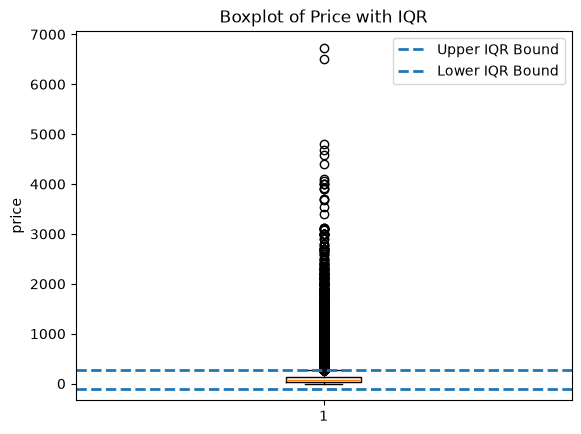

In [10]:
# 시각화
import matplotlib.pyplot as plt

plt.figure()

# 박스플롯
plt.boxplot(df['price'], showfliers=True)

# 경계선 표시
plt.axhline(upper, linestyle='--', linewidth=2, label='Upper IQR Bound')
plt.axhline(lower, linestyle='--', linewidth=2, label='Lower IQR Bound')

plt.title('Boxplot of Price with IQR')
plt.ylabel('price')
plt.legend()
plt.show()

In [77]:
print(df.columns)

Index(['delivery_latency_days', 'delivery_days', 'payment_value',
       'review_score', 'product_weight_g', 'freight_value'],
      dtype='object')


# 논리적 이상치 처리

In [11]:
# 1. 배송사 출고일이 승인일보다 빠른 경우

# pd.datetime(X) -> X를 datetime 객체로 바꿔 반환함
# datetime 객체는 일, 월, 연 변환 및 비교가 용이하여 날짜 컬럼은 datetime으로 바꾸는 것이 좋음

# 필요 컬럼 두 가지 datetime 객체로 변환하기

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
# ‘order_approved_at’ < ‘order_purchase_timestamp’
invalid_df1 = df[df['order_approved_at'] < df['order_purchase_timestamp']]

print(invalid_df1.shape)
invalid_df1.head()

(0, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state


In [12]:
# 2. 고객 수령일이 배송사 출발일보다 빠른 경우

# 필요 컬럼 두 가지 datetime 객체로 변환하기
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

# ‘order_delivered_customer_date’ < ‘order_delievered_carrier_date’
invalid_df2 = df[df['order_delivered_customer_date'] < df['order_delivered_carrier_date']]

print(invalid_df2.shape)
invalid_df2.head()

(58, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
2806,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08 00:00:00,2.0,77b61edc47d5dda4e6fb3568962d3e63,...,16.0,14.0,14.0,8518c7888966eddd34b73abcc5165b07,9791,sao bernardo do campo,SP,85863.0,foz do iguacu,PR
3471,29941903985f944b0ffc49c479c1547d,b56ee98181afc3948a758d73a08423de,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,2017-06-23 00:00:00,1.0,3006b8f5b476750a03137c1b2755cea1,...,16.0,16.0,16.0,bf0a805b588b889511e15496905cf7c5,16790,bento de abreu,SP,91350.0,porto alegre,RS
4551,b866af202be0692766081310cd4085e1,d1800078046ed2e5ae1b0792b695c56e,delivered,2017-01-27 14:59:17,2017-01-27 15:30:46,2017-02-20 02:32:08,2017-02-15 03:53:46,2017-04-17 00:00:00,2.0,63cbf4066cf395d6634831160ddacbbd,...,20.0,16.0,20.0,64fbafb2935c7a2588d6a26a9d750487,3063,sao paulo,SP,3168.0,sao paulo,SP
10172,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21 00:00:00,2.0,eff955ba97941dc6837a770367d66944,...,32.0,11.0,27.0,6ffbd33f8e881a046e7bdd228ce90c8a,33600,pedro leopoldo,MG,37580.0,monte siao,MG
14732,771c4f1f521f462e4b95619e648aaeab,d424b3ce4c850247e8c84ff8752de868,delivered,2017-03-22 20:15:15,2017-03-22 20:15:15,2017-03-30 13:14:34,2017-03-28 17:28:32,2017-04-12 00:00:00,1.0,a695ab8413ea83619cde9b18292d6aa1,...,23.0,7.0,23.0,bbc4d86624927ed9617d2664bf85d1dd,30330,belo horizonte,MG,36500.0,uba,MG


In [13]:
# 3. 리뷰 작성일이 고객 수령일보다 빠른 경우

# 필요 컬럼 두 가지 datetime 객체로 변환하기 (앞에서 했으면 안 해도 됨)
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

invalid_df3 = df[df['review_creation_date'] < df['order_delivered_customer_date']]

print(invalid_df3.shape)
invalid_df3.head()

(9335, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
21,0aed18a03ea2ccdb5981aea3524b304d,186d5e15485ff2afa04f02bd00aee4a4,delivered,2017-09-08 12:16:48,2017-09-12 04:55:21,2017-09-13 22:23:41,2017-09-23 01:23:34,2017-10-03 00:00:00,2.0,08574b074924071f4e201e151b152b4e,...,42.0,12.0,39.0,dc9108cdc59294eebe936e0971e6da63,60865,fortaleza,CE,29156.0,cariacica,ES
22,0aed18a03ea2ccdb5981aea3524b304d,186d5e15485ff2afa04f02bd00aee4a4,delivered,2017-09-08 12:16:48,2017-09-12 04:55:21,2017-09-13 22:23:41,2017-09-23 01:23:34,2017-10-03 00:00:00,1.0,98a8c2fa16d7239c606640f5555768e4,...,43.0,14.0,33.0,dc9108cdc59294eebe936e0971e6da63,60865,fortaleza,CE,29156.0,cariacica,ES
44,a5dcc015b748b353c2ddfb0939d36c58,289fd418dcc325a3820763155a982c51,delivered,2017-11-05 22:08:34,2017-11-07 05:32:00,2017-11-07 21:56:49,2017-11-14 01:38:34,2017-11-27 00:00:00,1.0,08574b074924071f4e201e151b152b4e,...,42.0,12.0,39.0,d31877e6feecf887ec4e9b95c30e6422,9271,santo andre,SP,29156.0,cariacica,ES
75,7b74647ef95b9578401bd8a4f723b301,43ae0f58c3e63919119fa948c2efee95,delivered,2017-12-01 01:42:46,2017-12-02 02:37:19,2017-12-04 19:48:32,2018-01-05 19:27:54,2017-12-29 00:00:00,1.0,0da9ffd92214425d880de3f94e74ce39,...,39.0,12.0,42.0,b703d83e085a6a8b339dc548f4878ca8,25070,duque de caxias,RJ,29156.0,cariacica,ES
86,ec97666defb2e1fade6931649731f776,4abad51a71113d2de9e00350623a66ec,delivered,2017-07-06 00:17:31,2017-07-07 08:23:33,2017-07-07 15:56:50,2017-07-31 18:34:28,2017-07-28 00:00:00,1.0,e251ebd2858be1aa7d9b2087a6992580,...,40.0,14.0,43.0,86b15d7e1a678212f2cf29f2f7a708ec,25576,sao joao de meriti,RJ,29156.0,cariacica,ES


In [ ]:
# 리뷰 작성일이 고객 수령일보다 빠른 것이 논리적 오류인가?
# 배달이 지연되는 경우, 수령하기 전에 구매 확정이 되어 리뷰 작성이 가능해졌을 가능성을 고려할 수 있음
# 판단은 자신의 몫 !

# 변수 변환

In [14]:
price_df = df[["price"]].copy()

In [17]:
# 표준화
# 평균을 0으로, 분산을 1로
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

price_df["price_standard"] = standard_scaler.fit_transform(price_df[["price"]])

In [19]:
# 정규화
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

price_df["price_minmax"] = minmax_scaler.fit_transform(price_df[["price"]])

In [20]:
price_df

,price,price_standard,price_minmax
0,895.0,4.279494,0.132778
1,895.0,4.279494,0.132778
2,895.0,4.279494,0.132778
3,99.0,-0.115222,0.014575
4,99.0,-0.115222,0.014575
...,...,...,...
118300,11.5,-0.598309,0.001581
118301,69.0,-0.280852,0.010120
118306,29.4,-0.499483,0.004240
118308,109.2,-0.058908,0.016090


# 상관분석 해보기

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화 스타일 설정
sns.set_palette('husl')
sns.set_style('whitegrid')

# 주문/배송 시각과 관련된 정보 불러오기
df_orders = pd.read_csv('olist_orders_dataset.csv')[[
    'order_id',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]]
df = df_orders.copy()

# 날짜 계산을 위한 전처리
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date'])

# 계산된 값으로 새로운 칼럼(배송 지연일, 배송 소요일)을 추가
# 배송 지연일, 배송 소요일을 계산하려면 어떤 컬럼을 사용하면 될까요?
df['delivery_latency_days'] = df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
df['delivery_days'] = df['order_delivered_customer_date'] - df['order_approved_at']

# 주문 별 결제 금액 정보 가져오기
df_payments = pd.read_csv('olist_order_payments_dataset.csv')[[
    'order_id',
    'payment_value',
]]
df = pd.merge(left=df, right=df_payments, on='order_id', how='left')

# 주문 별 리뷰 점수 정보 가져오기
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')[[
    'order_id',
    'review_score',
]]
df = pd.merge(left=df, right=df_reviews, on='order_id', how='left')

# =========================================
# 한 주문에는 상품이 여러 개 있을 수 있다.
# =========================================

# 주문에 포함된 상품 별 배송비 & 무게 정보 가져오기
df_product = pd.merge(
    left=pd.read_csv('olist_order_items_dataset.csv')[[
        'order_id',
        'product_id',
        'freight_value',
    ]],
    right=pd.read_csv('olist_products_dataset.csv')[[
        'product_id',
        'product_weight_g',
    ]],
    on='product_id',
    how='left',
)

# 주문 별로 상품 배송비 & 무게 정보 집계하기
# 그룹화 함수, 집계 함수를 활용해보세요.
df_product_agg = df_product[['order_id', 'product_weight_g', 'freight_value']] \
    .groupby('order_id') \
    .agg({
        'product_weight_g': 'sum',
        'freight_value': 'sum',
    }) \
    .reset_index()
df = pd.merge(left=df, right=df_product_agg, on='order_id', how='left')


# 사용하지 않을 칼럼 제거
df.drop(
    columns=[
        'order_id',
        'order_approved_at',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ],
    inplace=True,
)

df.head(10)

,delivery_latency_days,delivery_days,payment_value,review_score,product_weight_g,freight_value
0,-8 days +21:25:13,8 days 10:17:58,18.12,4.0,500.0,8.72
1,-8 days +21:25:13,8 days 10:17:58,2.00,4.0,500.0,8.72
2,-8 days +21:25:13,8 days 10:17:58,18.59,4.0,500.0,8.72
3,-6 days +15:27:45,12 days 12:03:18,141.46,4.0,400.0,22.76
4,-18 days +18:06:29,9 days 09:11:06,179.12,5.0,420.0,19.22
5,-13 days +00:28:42,13 days 04:42:43,72.20,5.0,450.0,27.20
6,-10 days +18:17:02,2 days 19:56:33,28.62,5.0,250.0,8.72
7,-6 days +10:57:55,16 days 12:47:42,175.26,4.0,7150.0,27.36
8,NaT,NaT,65.95,2.0,600.0,16.05
9,-12 days +12:55:51,9 days 23:33:40,75.16,5.0,50.0,15.17


<Axes: >

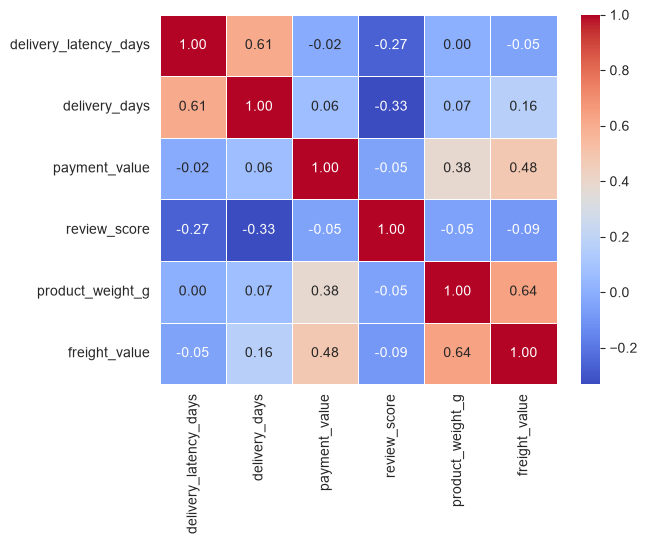

In [23]:
# 히트맵 그리기
import seaborn as sns
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

In [ ]:
# 값이 0보다 멀수록 두 변수가 강하게 관계되어 있다
# 강한 연관: product_weight_g <-> freight_value
# 약한 연관: delivery_days <-> payments_value

# 추가 변수 창출

In [25]:
df_items = pd.read_csv("olist_order_items_dataset.csv")
df_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_products = pd.read_csv("olist_products_dataset.csv")
df_sellers = pd.read_csv("olist_sellers_dataset.csv")
df_payments = pd.read_csv("olist_order_payments_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")

In [26]:
# CLV(Customer Lifetime Value) 고객 생애 가치 구하기
# CLV = 평균 구매 금액 (AOV) X  평균 구매 빈도 (F) X 고객 유지 시간 (L)

# Average Order Value (AOV) 평균 구매 금액  총 구매 금액 / 구매 횟수
# Purchase Frequency (F) 평균 구매 빈도 구매 횟수 / 활동 기간
# Customer Lifespan (L) 고객이 유지되는 기간 예: 1년, 또는 고객별 실제 기간

# AOV를 계산하기 위해 merge 해주기
df_order = pd.merge(df_orders, df_payments, on='order_id', how='left')
df_order_with_customer = pd.merge(df_order, df_customers, on='customer_id', how='left')


# 주문 및 결제 데이터 불러오기
# 사용자 별 총 구매 금액 데이터프레임# 주문 및 결제 데이터 불러오기
# 사용자 별 총 구매 금액 데이터프레임을 total_payment에 저장하세요
# customer_unique_id 컬럼을 활용하세요
total_payment = df_order_with_customer.groupby('customer_unique_id')['payment_value'].sum()
# 사용자 별 총 주문 수 데이터프레임을 total_orders에 저장하세요
total_orders = df_order_with_customer.groupby('customer_unique_id')['order_id'].nunique()

# 평균 구매금액 (Average Order Value)
aov = total_payment / total_orders

# 전체 기간(을 구하기 위해서는 str -> datetime 으로 형 변환을 해야한다)
timestamp = pd.to_datetime(df_order['order_purchase_timestamp'])
period = (timestamp.max() - timestamp.min()) # 데이터의 전체 기간
total_months = period.days / 30 # 기간의 개월 수

print(f'{period=}')

# 구매 빈도 (월 단위)
# Hint: 이미 구함
frequency = total_orders # 고객 별 period 내 구매 횟수

# 고객 생애 가치 계산 (고객의 수명은 6개월로 가정)
clv = aov * (frequency / total_months) * 6 # 빈도의 월 평균을 기준으로 6개월로 가정
print(clv)

period=Timedelta('772 days 20:14:59')
customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2     33.085492
0000b849f77a49e4a4ce2b2a4ca5be3f      6.339637
0000f46a3911fa3c0805444483337064     20.103109
0000f6ccb0745a6a4b88665a16c9f078     10.170466
0004aac84e0df4da2b147fca70cf8255     45.906995
                                       ...    
fffcf5a5ff07b0908bd4e2dbc735a684    482.040933
fffea47cd6d3cc0a88bd621562a9d061     19.720725
ffff371b4d645b6ecea244b27531430a     26.221244
ffff5962728ec6157033ef9805bacc48     31.171244
ffffd2657e2aad2907e67c3e9daecbeb     16.684974
Length: 96096, dtype: float64


In [97]:
# dataframe 형태로 변환
clv = clv.reset_index()
clv.columns = ['customer_id', 'clv']

clv.head()

,customer_id,clv
0,0000366f3b9a7992bf8c76cfdf3221e2,33.085492
1,0000b849f77a49e4a4ce2b2a4ca5be3f,6.339637
2,0000f46a3911fa3c0805444483337064,20.103109
3,0000f6ccb0745a6a4b88665a16c9f078,10.170466
4,0004aac84e0df4da2b147fca70cf8255,45.906995


In [27]:
# dataframe 형태로 변환
aov = aov.reset_index()
aov.columns = ['customer_id', 'aov']

aov.head()

,customer_id,aov
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [28]:
# dataframe 형태로 변환
frequency = frequency.reset_index()
frequency.columns = ['customer_id', 'frequency']

frequency.head()

,customer_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
